In [2]:
%load_ext autoreload
%autoreload 2

import os, sys, pathlib

ROOT = pathlib.Path.cwd()
while not (ROOT / 'crossmatching').exists():
    ROOT = ROOT.parent
os.chdir(ROOT)

import numpy as np
from astropy.table import Table, Column
from astropy import units as u
import matplotlib.pyplot as plt
import matplotlib as mpl
from IPython.display import display, HTML
from crossmatching import Crossmatcher, EMCCatalog, EMCIdSupplier, NEACatalog, SimbadIdSupplier, ParamFiller, temperate_mask, rocky_mask
from crossmatching.enrichment import (
    HpicParamSource, NeaParamSource, SimbadParamSource,
    EpicParamSource, ToiParamSource, EuParamSource
)
from crossmatching.enrichment import classify_spectral_type

import numpy as np
from astropy.table import Table
from astropy.io import ascii
import astropy.units as u
from astropy.coordinates import SkyCoord

from astroquery.simbad import Simbad
from collections import Counter
import timeit
import matplotlib.pyplot as plt
import pandas
import os
import numpy.ma as ma
import plotly.graph_objects as go

In [8]:
input_table = ascii.read("./input/HPIC_LC4_combined_d50.txt")


cme = Crossmatcher(EMCCatalog(), EMCIdSupplier(), default_search_radius=50*u.arcsec)
cme.load_catalog(from_file="./input/exo-mercat.csv")

cme.load_alternate_ids(input_table["star_name"], from_file="./input/exo-mercat.csv")

# emc_result = cme.combined_crossmatch(input_table, input_starname_key="star_name")
matched = cme.combined_crossmatch(input_table, "star_name")
id_matched_planets = matched[matched["match_type"] != "coordinates"]
len(matched), len(id_matched_planets)

(1295, 1285)

In [4]:
id_matched = cme.remove_duplicates(id_matched_planets, "star_name", from_file="./input/exo-mercat.csv")
id_matched.sort("crossmatching_angular_separation")
len(id_matched)

704

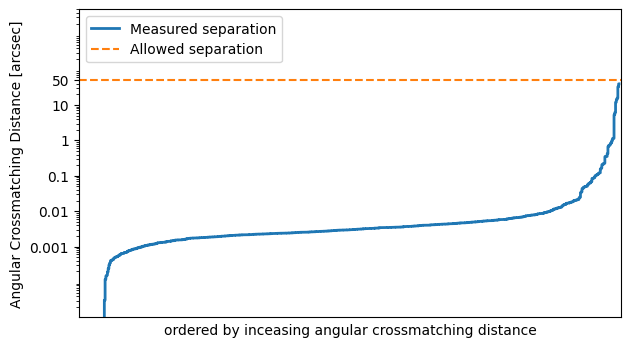

In [24]:
from matplotlib.ticker import FixedFormatter, FixedLocator


fig, ax = plt.subplots(figsize=(7, 4))

x = np.array(range(len(id_matched)))

plt.step(x, id_matched["crossmatching_angular_separation"], where="mid", lw=2, label="Measured separation")
plt.xlim(-2,len(id_matched)+2)
plt.yscale("log")
plt.axhline(50, linestyle="--", color="tab:orange", label="Allowed separation")
tick_values = [1E-3,1E-2, 1E-1, 1, 10, 50]
ax.yaxis.set_major_locator(FixedLocator(tick_values))
ax.yaxis.set_major_formatter(FixedFormatter([f"{i}" for i in tick_values]))
ax.xaxis.set_major_formatter(FixedFormatter([]))
plt.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)

ax.set_xlim(-5,len(id_matched) + 2)
ax.set_ylim(0.00001,5000)
ax.set_ylabel("Angular Crossmatching Distance [arcsec]")
ax.set_xlabel("ordered by inceasing angular crossmatching distance")
ax.legend(loc="upper left")

plt.savefig("./input/emc_coord_calibration.pdf", bbox_inches="tight", dpi=300)

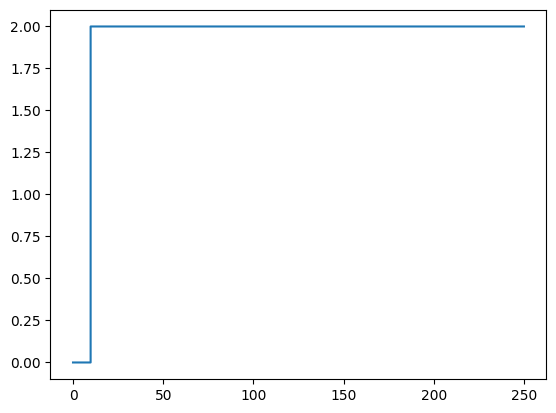

In [6]:
coords = SkyCoord(ra=id_matched["ra"]*u.deg, dec=id_matched["dec"]*u.deg)
idx, sep, sep3d = coords.match_to_catalog_sky(coords, nthneighbor=2)
# (sep*u.deg < id_matched["crossmatching_angular_separation"]*u.arcsec).sum()

x2 = np.linspace(0,250,1000)
y2= [np.sum(np.array(sep) <= i*u.arcsec.to(u.deg)) for i in x2]

plt.step(x2,y2, where="pre")
# plt.yscale("log")


In [7]:
y2

[np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.in